# Assignment Experiment

In [1]:
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *
%reload_ext autoreload
%autoreload 2
import helpers, helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment

**Goal: compare Local vs Global vs Hungarian assigments algorithms.**  
To this aim, we use the following params: 

In [2]:
D = [0,1,2,3,4]
F = 50
N = 25

In [3]:
frames, trajectories_GT, D_GT = generate_frames_OOP(F, N, amp = 1000, noise_gaussian = True, noise_poisson = True)

Frame 0
Frame 10
Frame 20
Frame 30
Frame 40


In [4]:
print(D_GT)

[2, 2, 3, 4, 1, 0, 1, 4, 2, 3, 0, 4, 0, 0, 1, 3, 4, 1, 0, 4, 4, 2, 1, 0, 3]


In [5]:
view_frames(frames)

In [6]:
check_min_max(frames[2])

min: 1.160996497995154e-179
max: 1751.8881791930075


Fitted center for peak at (20, 107): (20.00, 107.17), amplitude 1020.01, sigma 0.51


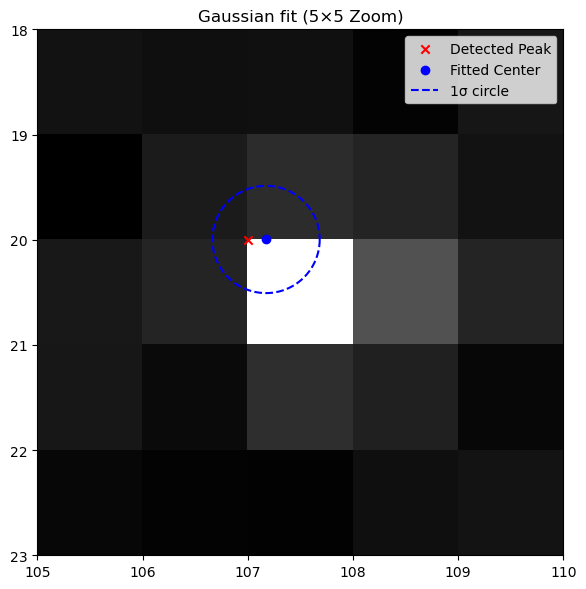

Fitted center for peak at (71, 124): (70.88, 123.98), amplitude 986.18, sigma 0.50
Fitted center for peak at (68, 118): (67.98, 117.77), amplitude 1065.66, sigma 0.51
Fitted center for peak at (50, 13): (50.08, 12.73), amplitude 1109.90, sigma 0.48
Fitted center for peak at (3, 35): (2.96, 34.82), amplitude 935.90, sigma 0.53
Fitted center for peak at (96, 81): (96.38, 81.01), amplitude 1113.59, sigma 0.46
Fitted center for peak at (59, 37): (59.03, 36.63), amplitude 1119.90, sigma 0.43
Fitted center for peak at (108, 97): (107.86, 96.78), amplitude 885.22, sigma 0.55
Fitted center for peak at (44, 118): (43.63, 117.60), amplitude 3633.81, sigma 0.30
Fitted center for peak at (107, 55): (106.70, 54.84), amplitude 931.41, sigma 0.53
Fitted center for peak at (125, 79): (125.40, 79.19), amplitude 1218.43, sigma 0.44
Fitted center for peak at (45, 46): (45.43, 45.84), amplitude 1074.07, sigma 0.50
Fitted center for peak at (35, 69): (34.94, 69.38), amplitude 916.77, sigma 0.52
Fitted cent

In [7]:
trajectories_detection, trajectories_localization = compute_d_l_trajectories(frames, trajectories_GT, D_GT)

In [8]:
print(len(trajectories_detection), len(trajectories_localization))

45 48


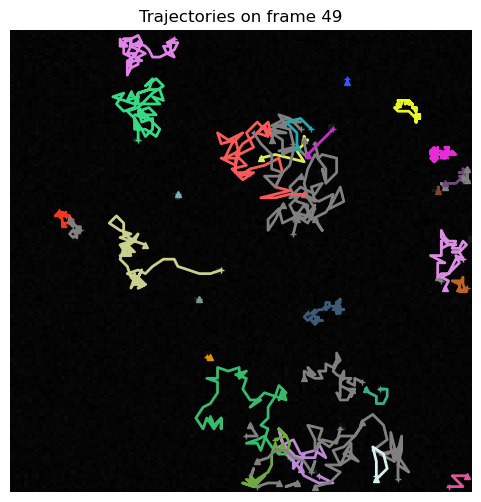

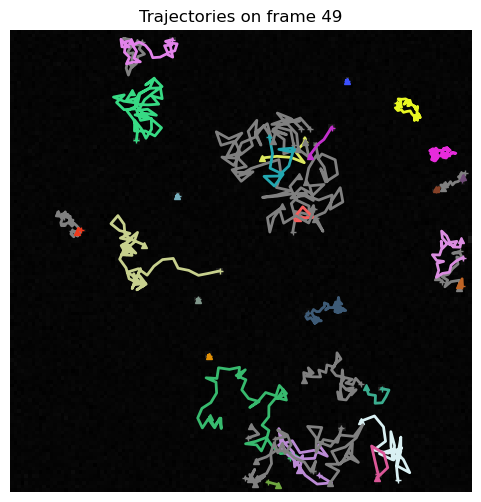

In [15]:
show_trajectories(frames, trajectories_detection, frame_id = 49)
show_trajectories(frames, trajectories_localization, frame_id = 49)


### 1. Local NN assignment

In [10]:
trajectories_d_local, min_cost_d_local, assignment_d_local, trajectories_l_local, min_cost_l_local, assignment_l_local = assign_d_l_trajectories(trajectories_detection, trajectories_localization, trajectories_GT, algorithm='local_nn', verbose=True)

Detection assignment:
new[0] (0->49) -> gt[22] (0->49)
new[1] (0->8) -> gt[21] (0->49)
new[2] (0->1) -> gt[1] (0->49)
new[3] (0->26) -> gt[6] (0->49)
new[4] (0->49) -> gt[8] (0->49)
new[5] (0->40) -> gt[0] (0->49)
new[6] (0->49) -> gt[9] (0->49)
new[7] (0->21) -> gt[11] (0->49)
new[8] (0->49) -> gt[12] (0->49)
new[9] (0->49) -> gt[2] (0->49)
new[10] (0->2) -> gt[24] (0->49)
new[11] (0->49) -> gt[23] (0->49)
new[12] (0->49) -> gt[10] (0->49)
new[13] (0->49) -> gt[5] (0->49)
new[14] (0->49) -> gt[18] (0->49)
new[15] (0->21) -> gt[7] (0->49)
new[16] (0->3) -> gt[20] (0->49)
new[17] (0->26) -> gt[16] (0->49)
new[18] (0->49) -> gt[13] (0->49)
new[19] (0->49) -> gt[17] (0->49)
new[20] (0->19) -> gt[3] (0->49)
new[21] (0->49) -> gt[15] (0->49)
new[22] (0->3) -> gt[19] (0->49)
new[23] (0->49) -> gt[4] (0->49)
new[24] (3->40) -> gt[1] (0->49)
new[25] (4->6) -> gt[16] (0->49)
new[26] (8->49) -> gt[19] (0->49)
new[27] (8->14) -> gt[24] (0->49)
new[28] (11->13) -> gt[14] (0->49)
new[29] (15->33) -

### 2. Global NN assignment

In [11]:
trajectories_d_global, min_cost_d_global, assignment_d_global, trajectories_l_global, min_cost_l_global, assignment_l_global = assign_d_l_trajectories(trajectories_detection, trajectories_localization, trajectories_GT, algorithm='global_nn', verbose=True)

Detection assignment:
new[0] (0->49) -> gt[22] (0->49)
new[1] (0->8) -> gt[21] (0->49)
new[2] (0->1) -> unassigned
new[3] (0->26) -> gt[6] (0->49)
new[4] (0->49) -> gt[8] (0->49)
new[5] (0->40) -> unassigned
new[6] (0->49) -> gt[9] (0->49)
new[7] (0->21) -> unassigned
new[8] (0->49) -> gt[12] (0->49)
new[9] (0->49) -> gt[2] (0->49)
new[10] (0->2) -> unassigned
new[11] (0->49) -> gt[23] (0->49)
new[12] (0->49) -> gt[10] (0->49)
new[13] (0->49) -> gt[5] (0->49)
new[14] (0->49) -> gt[18] (0->49)
new[15] (0->21) -> gt[7] (0->49)
new[16] (0->3) -> gt[20] (0->49)
new[17] (0->26) -> unassigned
new[18] (0->49) -> gt[13] (0->49)
new[19] (0->49) -> gt[17] (0->49)
new[20] (0->19) -> unassigned
new[21] (0->49) -> gt[15] (0->49)
new[22] (0->3) -> unassigned
new[23] (0->49) -> gt[4] (0->49)
new[24] (3->40) -> gt[1] (0->49)
new[25] (4->6) -> unassigned
new[26] (8->49) -> gt[19] (0->49)
new[27] (8->14) -> unassigned
new[28] (11->13) -> unassigned
new[29] (15->33) -> gt[14] (0->49)
new[30] (16->37) -> 

### 3. Hungarian assignment

In [12]:
trajectories_d_hungarian, min_cost_d_hungarian, assignment_d_hungarian, trajectories_l_hungarian, min_cost_l_hungarian, assignment_l_hungarian = assign_d_l_trajectories(trajectories_detection, trajectories_localization, trajectories_GT, algorithm='hungarian', verbose=True)

Detection assignment:
new[0] (0->49) -> gt[22] (0->49)
new[1] (0->8) -> gt[21] (0->49)
new[2] (0->1) -> unassigned
new[3] (0->26) -> gt[6] (0->49)
new[4] (0->49) -> gt[8] (0->49)
new[5] (0->40) -> unassigned
new[6] (0->49) -> gt[9] (0->49)
new[7] (0->21) -> unassigned
new[8] (0->49) -> gt[12] (0->49)
new[9] (0->49) -> gt[2] (0->49)
new[10] (0->2) -> unassigned
new[11] (0->49) -> gt[23] (0->49)
new[12] (0->49) -> gt[10] (0->49)
new[13] (0->49) -> gt[5] (0->49)
new[14] (0->49) -> gt[18] (0->49)
new[15] (0->21) -> gt[7] (0->49)
new[16] (0->3) -> gt[20] (0->49)
new[17] (0->26) -> unassigned
new[18] (0->49) -> gt[13] (0->49)
new[19] (0->49) -> gt[17] (0->49)
new[20] (0->19) -> unassigned
new[21] (0->49) -> gt[15] (0->49)
new[22] (0->3) -> unassigned
new[23] (0->49) -> gt[4] (0->49)
new[24] (3->40) -> gt[1] (0->49)
new[25] (4->6) -> unassigned
new[26] (8->49) -> gt[19] (0->49)
new[27] (8->14) -> unassigned
new[28] (11->13) -> unassigned
new[29] (15->33) -> gt[14] (0->49)
new[30] (16->37) -> 

### 4. Comparison -> minimum cost

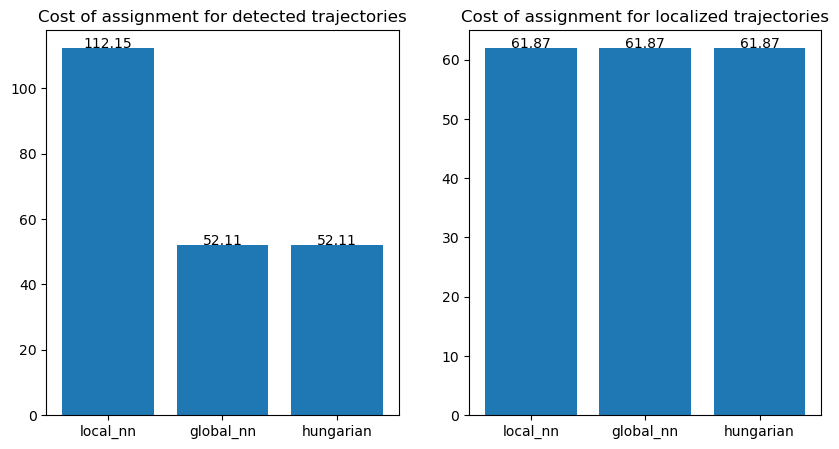

In [13]:
# plot comparison of the algrorithms based on the cost of the assignment
algorithms = ['local_nn', 'global_nn', 'hungarian']
costs_d = [min_cost_d_local, min_cost_d_global, min_cost_d_hungarian]
costs_l = [min_cost_l_local, min_cost_l_global, min_cost_l_hungarian]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(algorithms, costs_d)
plt.title('Cost of assignment for detected trajectories')
for i, cost in enumerate(costs_d):
    plt.text(i, cost + 0.1, f'{cost:.2f}', ha='center')
plt.subplot(1,2,2)
plt.bar(algorithms, costs_l)
plt.title('Cost of assignment for localized trajectories')
for i, cost in enumerate(costs_l):
    plt.text(i, cost + 0.1, f'{cost:.2f}', ha='center')
plt.show()

-> cost for dists between found and?? GT??